In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/amankumar2002/ml4sci-test-1/dataset/val/no/422.npy
/kaggle/input/datasets/amankumar2002/ml4sci-test-1/dataset/val/no/331.npy
/kaggle/input/datasets/amankumar2002/ml4sci-test-1/dataset/val/no/2434.npy
/kaggle/input/datasets/amankumar2002/ml4sci-test-1/dataset/val/no/280.npy
/kaggle/input/datasets/amankumar2002/ml4sci-test-1/dataset/val/no/970.npy
/kaggle/input/datasets/amankumar2002/ml4sci-test-1/dataset/val/no/2467.npy
/kaggle/input/datasets/amankumar2002/ml4sci-test-1/dataset/val/no/2424.npy
/kaggle/input/datasets/amankumar2002/ml4sci-test-1/dataset/val/no/745.npy
/kaggle/input/datasets/amankumar2002/ml4sci-test-1/dataset/val/no/100.npy
/kaggle/input/datasets/amankumar2002/ml4sci-test-1/dataset/val/no/1200.npy
/kaggle/input/datasets/amankumar2002/ml4sci-test-1/dataset/val/no/1170.npy
/kaggle/input/datasets/amankumar2002/ml4sci-test-1/dataset/val/no/1876.npy
/kaggle/input/datasets/amankumar2002/ml4sci-test-1/dataset/val/no/719.npy
/kaggle/input/datasets/amankumar

In [2]:
import os

print(os.listdir("/kaggle/input"))

['datasets']


In [3]:
print(os.listdir("/kaggle/input/datasets"))

['amankumar2002']


In [3]:
TRAIN_DIR = "/kaggle/input/datasets/amankumar2002/ml4sci-test-1/dataset/train"
VAL_DIR   = "/kaggle/input/datasets/amankumar2002/ml4sci-test-1/dataset/val"

In [4]:
from __future__ import annotations
 
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║   PINN for Gravitational Lens Classification — FINAL WORKING VERSION       ║
# ║   Kaggle T4 x2  |  ResNet backbone  |  Physics-Informed Loss              ║
# ╚══════════════════════════════════════════════════════════════════════════════╝
 
# ══════════════════════════════════════════════════════════════════════════════
# CELL 1 — Imports, paths, device
# ══════════════════════════════════════════════════════════════════════════════
import os, math, time, json, random, logging
from pathlib import Path
from typing import Dict, List, Tuple
from dataclasses import dataclass
 
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torch.amp import GradScaler, autocast
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
 
TRAIN_DIR = "/kaggle/input/datasets/amankumar2002/ml4sci-test-1/dataset/train"
VAL_DIR   = "/kaggle/input/datasets/amankumar2002/ml4sci-test-1/dataset/val"
CKPT_DIR  = "/kaggle/working/checkpoints"
SAVE_DIR  = "/kaggle/working/plots"
os.makedirs(CKPT_DIR, exist_ok=True)
os.makedirs(SAVE_DIR,  exist_ok=True)
 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device      : {device}")
if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        cap = torch.cuda.get_device_capability(i)
        print(f"GPU {i}       : {torch.cuda.get_device_name(i)}  (sm_{cap[0]}{cap[1]})")

Device      : cuda
GPU 0       : Tesla T4  (sm_75)
GPU 1       : Tesla T4  (sm_75)


In [5]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 2 — Logger
# ══════════════════════════════════════════════════════════════════════════════
def get_logger(name: str) -> logging.Logger:
    logger = logging.getLogger(name)
    if not logger.handlers:
        h = logging.StreamHandler()
        h.setFormatter(logging.Formatter(
            "%(asctime)s | %(levelname)-8s | %(name)s | %(message)s",
            datefmt="%H:%M:%S"))
        logger.addHandler(h)
    logger.setLevel(logging.INFO)
    return logger
 
log = get_logger("pinn")

In [6]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 3 — Dataset & transforms
# ══════════════════════════════════════════════════════════════════════════════
CLASS_NAMES  = ["no", "sphere", "vort"]
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASS_NAMES)}
 
 
class DeepLenseDataset(Dataset):
    def __init__(self, root, transform=None):
        self.root      = Path(root)
        self.transform = transform
        self.samples: List[Tuple[Path, int]] = []
        for cls in CLASS_NAMES:
            cls_dir = self.root / cls
            if not cls_dir.exists():
                raise FileNotFoundError(cls_dir)
            for f in sorted(cls_dir.glob("*.npy")):
                self.samples.append((f, CLASS_TO_IDX[cls]))
        log.info("Loaded %d samples from %s", len(self.samples), self.root)
 
    def __len__(self):
        return len(self.samples)
 
    def __getitem__(self, idx):
        path, label = self.samples[idx]
        arr = np.load(path).astype(np.float32)
        if arr.ndim == 2:
            arr = arr[np.newaxis]
        img = torch.from_numpy(arr)
        if self.transform:
            img = self.transform(img)
        return img, label
 
 
def build_transforms(train: bool) -> transforms.Compose:
    norm = transforms.Normalize([0.5], [0.25])
    if train:
        return transforms.Compose([
            transforms.RandomHorizontalFlip(0.5),
            transforms.RandomVerticalFlip(0.5),
            transforms.RandomRotation(30),
            norm,
        ])
    return transforms.Compose([norm])
 
 
def build_loaders(train_dir, val_dir, batch_size=64, num_workers=2):
    tds = DeepLenseDataset(train_dir, build_transforms(True))
    vds = DeepLenseDataset(val_dir,   build_transforms(False))
    tl  = DataLoader(tds, batch_size=batch_size, shuffle=True,
                     num_workers=num_workers, pin_memory=True,
                     drop_last=True, persistent_workers=True)
    vl  = DataLoader(vds, batch_size=batch_size * 2, shuffle=False,
                     num_workers=num_workers, pin_memory=True,
                     persistent_workers=True)
    return tl, vl

In [7]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 4 — Model
# ══════════════════════════════════════════════════════════════════════════════
 
class ResBlock(nn.Module):
    """Standard residual block — well-conditioned gradients from random init."""
    def __init__(self, ch: int, stride: int = 1):
        super().__init__()
        out_ch = ch * stride
        self.conv1 = nn.Conv2d(ch, out_ch, 3, stride=stride, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(out_ch)
        self.skip  = nn.Sequential(
            nn.Conv2d(ch, out_ch, 1, stride=stride, bias=False),
            nn.BatchNorm2d(out_ch)
        ) if stride > 1 else nn.Identity()
 
    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)), inplace=True)
        out = self.bn2(self.conv2(out))
        return F.relu(out + self.skip(x), inplace=True)
 
 
class SpatialAttention(nn.Module):
    """CBAM spatial attention — focuses on lens arc/ring regions."""
    def __init__(self):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, 7, padding=3, bias=False)
        self.bn   = nn.BatchNorm2d(1)
 
    def forward(self, x):
        avg   = x.mean(1, keepdim=True)
        mx, _ = x.max(1, keepdim=True)
        attn  = torch.sigmoid(self.bn(self.conv(torch.cat([avg, mx], 1))))
        return x * attn, attn
 
 
class PhysicsDecoder(nn.Module):
    """
    Predicts lensing potential psi and deflection field alpha.
    Final layers zero-initialised so psi=0, alpha=0 at start.
    """
    def __init__(self, in_ch: int):
        super().__init__()
        self.neck = nn.Sequential(
            nn.Conv2d(in_ch, 64, 1, bias=False),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True))
        self.psi_head = nn.Sequential(
            nn.Conv2d(64, 32, 3, padding=1, bias=False),
            nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.Conv2d(32, 1, 1, bias=True))
        self.alpha_head = nn.Sequential(
            nn.Conv2d(64, 32, 3, padding=1, bias=False),
            nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.Conv2d(32, 2, 1, bias=True))
        nn.init.zeros_(self.psi_head[-1].weight)
        nn.init.zeros_(self.psi_head[-1].bias)
        nn.init.zeros_(self.alpha_head[-1].weight)
        nn.init.zeros_(self.alpha_head[-1].bias)
 
    def forward(self, x):
        x = self.neck(x)
        return self.psi_head(x), self.alpha_head(x)
 
 
class GravLensPINN(nn.Module):
    """
    ResNet-style PINN for gravitational lens classification.
    150x150 -> stem(75x75) -> L1(75) -> L2(38) -> L3(19) -> L4(10) -> GAP -> cls
    Physics decoder runs on detached features.
    """
    def __init__(self, in_channels=1, num_classes=3, dropout_p=0.2):
        super().__init__()
        self.stem   = nn.Sequential(
            nn.Conv2d(in_channels, 32, 3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(32), nn.ReLU(inplace=True))
        self.layer1 = nn.Sequential(ResBlock(32),            ResBlock(32))
        self.layer2 = nn.Sequential(ResBlock(32,  stride=2), ResBlock(64))
        self.layer3 = nn.Sequential(ResBlock(64,  stride=2), ResBlock(128))
        self.layer4 = nn.Sequential(ResBlock(128, stride=2), ResBlock(256))
        self.attention = SpatialAttention()
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(256, 128, bias=False),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout_p),
            nn.Linear(128, num_classes))
        self.physics_decoder = PhysicsDecoder(in_ch=256)
        self._init_weights()
 
    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
                if m.bias is not None: nn.init.zeros_(m.bias)
            elif isinstance(m, (nn.BatchNorm2d, nn.BatchNorm1d)):
                nn.init.ones_(m.weight); nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.trunc_normal_(m.weight, std=0.02)
                if m.bias is not None: nn.init.zeros_(m.bias)
 
    def forward(self, x: torch.Tensor) -> Dict[str, torch.Tensor]:
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        feat, attn_map = self.attention(x)
        logits = self.classifier(feat)
        psi, alpha = self.physics_decoder(feat.detach())
        return {"logits": logits, "psi": psi,
                "alpha": alpha, "attn_map": attn_map}
 
    @torch.no_grad()
    def predict_with_uncertainty(self, x, mc_passes=20):
        self.eval()
        for m in self.modules():
            if isinstance(m, nn.Dropout): m.train()
        probs = torch.stack([
            F.softmax(self(x)["logits"], -1) for _ in range(mc_passes)])
        mean, std = probs.mean(0), probs.std(0)
        entropy = -(mean * (mean + 1e-8).log()).sum(-1)
        self.eval()
        return {"mean_probs": mean, "std_probs": std,
                "entropy": entropy, "pred_class": mean.argmax(-1)}
 
 
n_params = sum(p.numel() for p in GravLensPINN().parameters() if p.requires_grad)
print(f"Model params: {n_params:,}")
 
 


Model params: 2,881,578


In [8]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 5 — Physics loss
# ══════════════════════════════════════════════════════════════════════════════
 
class PhysicsLoss(nn.Module):
    """
    Gravitational lensing constraints (thin-lens approximation):
      Poisson       : nabla^2 psi = kappa  (convergence)
      Curl-free     : nabla x alpha = 0
      Gradient cons : alpha = nabla psi
      Smoothness    : ||nabla alpha||^2
    """
    def __init__(self, poisson_w=0.01, curl_w=0.01, gradient_w=0.01, smooth_w=0.001):
        super().__init__()
        self.pw, self.cw, self.gw, self.sw = poisson_w, curl_w, gradient_w, smooth_w
        self.register_buffer("lap_k", torch.tensor(
            [[[[0., 1., 0.], [1., -4., 1.], [0., 1., 0.]]]], dtype=torch.float32))
        self.register_buffer("dx_k", torch.tensor(
            [[[[-0.5, 0., 0.5]]]], dtype=torch.float32))
        self.register_buffer("dy_k", torch.tensor(
            [[[[-0.5], [0.], [0.5]]]], dtype=torch.float32))
 
    def _c(self, k, dt): return k.to(dtype=dt)
    def _lap(self, f):   return F.conv2d(f, self._c(self.lap_k, f.dtype), padding=1)
    def _dx(self, f):    return F.conv2d(f, self._c(self.dx_k,  f.dtype), padding=(0, 1))
    def _dy(self, f):    return F.conv2d(f, self._c(self.dy_k,  f.dtype), padding=(1, 0))
 
    def forward(self, psi, alpha, image):
        H, W  = psi.shape[2], psi.shape[3]
        kappa = F.interpolate(image.float(), (H, W), mode="bilinear",
                              align_corners=False).to(psi.dtype)
        p, a, k = psi.float(), alpha.float(), kappa.float()
        ax, ay  = a[:, 0:1], a[:, 1:2]
        l_pois = torch.clamp(((self._lap(p) - k) ** 2).mean(),                           max=10.)
        l_curl = torch.clamp(((self._dx(ay) - self._dy(ax)) ** 2).mean(),                max=10.)
        l_grad = torch.clamp(((ax - self._dx(p)) ** 2 + (ay - self._dy(p)) ** 2).mean(), max=10.)
        l_smth = torch.clamp((
            (self._dx(ax) ** 2).mean() + (self._dy(ax) ** 2).mean() +
            (self._dx(ay) ** 2).mean() + (self._dy(ay) ** 2).mean()),                    max=10.)
        total = self.pw*l_pois + self.cw*l_curl + self.gw*l_grad + self.sw*l_smth
        return {"poisson": l_pois, "curl": l_curl, "gradient": l_grad,
                "smooth": l_smth, "total": total}

In [9]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 6 — Config & helpers
# ══════════════════════════════════════════════════════════════════════════════
 
@dataclass
class Config:
    train_dir: str  = TRAIN_DIR
    val_dir:   str  = VAL_DIR
    ckpt_dir:  str  = CKPT_DIR
 
    batch_size:  int   = 64
    num_workers: int   = 2
    num_classes: int   = 3
    in_channels: int   = 1
    dropout_p:   float = 0.2
 
    lr:           float = 5e-4
    weight_decay: float = 1e-4
    grad_clip:    float = 1.0
 
    epochs:        int = 30
    warmup_epochs: int = 5
 
    lambda_start:         float = 0.0
    lambda_end:           float = 0.3
    lambda_warmup_epochs: int   = 25
 
    label_smoothing:     float = 0.05
    early_stop_patience: int   = 15
    log_every:           int   = 100
    seed:                int   = 42
    use_amp:             bool  = True
 
 
class AverageMeter:
    def __init__(self): self.reset()
    def reset(self): self.sum = self.count = 0.0
    def update(self, v, n=1): self.sum += v * n; self.count += n
    @property
    def avg(self): return self.sum / max(self.count, 1)
 
 
class LambdaAnnealer:
    def __init__(self, start, end, warmup):
        self.start, self.end, self.warmup = start, end, max(warmup, 1)
    def get(self, epoch):
        if epoch >= self.warmup: return self.end
        return self.start + (epoch / self.warmup) * (self.end - self.start)
 
 
class EarlyStopping:
    """
    Saves raw_model.state_dict() — never the DataParallel wrapper.
    This means the checkpoint is always loadable without stripping
    'module.' prefixes, regardless of how many GPUs were used.
    """
    def __init__(self, patience, delta, path):
        self.patience, self.delta, self.path = patience, delta, path
        self.best = float("inf"); self.counter = 0; self.best_epoch = 0
 
    def step(self, val, model, epoch):
        # Always unwrap before saving
        save_model = model.module if isinstance(model, nn.DataParallel) else model
        if val < self.best - self.delta:
            self.best = val; self.counter = 0; self.best_epoch = epoch
            torch.save(save_model.state_dict(), self.path)
            log.info("  checkmark Best val_loss=%.4f saved -> %s", val, self.path)
        else:
            self.counter += 1
            log.info("  x No improvement (%d/%d)", self.counter, self.patience)
            if self.counter >= self.patience:
                log.info("Early stopping at epoch %d", epoch)
                return True
        return False
 
 
class WarmupCosineScheduler(torch.optim.lr_scheduler._LRScheduler):
    def __init__(self, opt, warmup_steps, total_steps, eta_min=1e-6, last_epoch=-1):
        self.warmup_steps = warmup_steps
        self.total_steps  = total_steps
        self.eta_min      = eta_min
        super().__init__(opt, last_epoch)
 
    def get_lr(self):
        s = self.last_epoch
        if s < self.warmup_steps:
            f = s / max(self.warmup_steps, 1)
        else:
            p = (s - self.warmup_steps) / max(self.total_steps - self.warmup_steps, 1)
            f = 0.5 * (1 + math.cos(math.pi * p))
        return [max(self.eta_min, b * f) for b in self.base_lrs]
 
 
def seed_everything(s):
    random.seed(s); np.random.seed(s)
    torch.manual_seed(s); torch.cuda.manual_seed_all(s)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False
 
 


In [10]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 7 — Training loop
# ══════════════════════════════════════════════════════════════════════════════
 
def run_train_epoch(model, loader, optimizer, scheduler, scaler,
                    criterion, phys_fn, lam, device, cfg, epoch):
    model.train()
    m = {k: AverageMeter() for k in
         ["total", "cls", "phys_total", "phys_pois", "phys_curl", "phys_grad", "acc"]}
 
    for i, (imgs, labels) in enumerate(loader):
        imgs   = imgs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        B      = imgs.size(0)
 
        optimizer.zero_grad(set_to_none=True)
 
        with autocast("cuda", enabled=cfg.use_amp):
            out      = model(imgs)
            cls_loss = criterion(out["logits"], labels)
            pd       = phys_fn(out["psi"], out["alpha"], imgs)
            loss     = cls_loss + lam * pd["total"]
 
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()
 
        with torch.no_grad():
            acc = (out["logits"].argmax(-1) == labels).float().mean().item()
 
        m["total"].update(loss.item(), B)
        m["cls"].update(cls_loss.item(), B)
        m["phys_total"].update(pd["total"].item(), B)
        m["phys_pois"].update(pd["poisson"].item(), B)
        m["phys_curl"].update(pd["curl"].item(), B)
        m["phys_grad"].update(pd["gradient"].item(), B)
        m["acc"].update(acc, B)
 
        if (i + 1) % cfg.log_every == 0:
            log.info("E%02d [%4d/%d] loss=%.4f cls=%.4f phys=%.4f "
                     "(pois=%.4f curl=%.4f grad=%.4f) acc=%.3f lam=%.3f",
                     epoch, i + 1, len(loader),
                     m["total"].avg, m["cls"].avg, m["phys_total"].avg,
                     m["phys_pois"].avg, m["phys_curl"].avg, m["phys_grad"].avg,
                     m["acc"].avg, lam)
 
    return {k: v.avg for k, v in m.items()}
 
 
@torch.no_grad()
def run_val_epoch(model, loader, criterion, device, cfg):
    model.eval()
    m = {k: AverageMeter() for k in ["cls", "acc"]}
    for imgs, labels in loader:
        imgs   = imgs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        with autocast("cuda", enabled=cfg.use_amp):
            out      = model(imgs)
            cls_loss = criterion(out["logits"], labels)
        acc = (out["logits"].argmax(-1) == labels).float().mean().item()
        m["cls"].update(cls_loss.item(), imgs.size(0))
        m["acc"].update(acc, imgs.size(0))
    return {k: v.avg for k, v in m.items()}

In [11]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 8 — Evaluation
# ══════════════════════════════════════════════════════════════════════════════
 
def evaluate(model, val_dir, device, cfg, mc_passes=20):
    """model must be the unwrapped GravLensPINN (no DataParallel)."""
    vds = DeepLenseDataset(val_dir, build_transforms(False))
    vl  = DataLoader(vds, batch_size=256, shuffle=False,
                     num_workers=2, pin_memory=True)
 
    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in vl:
            p = F.softmax(model(imgs.to(device))["logits"], -1)
            all_probs.append(p.cpu()); all_labels.append(labels)
 
    probs  = torch.cat(all_probs).numpy()
    labels = torch.cat(all_labels).numpy()
    preds  = probs.argmax(1)
    acc    = (labels == preds).mean()
    try:
        auc = roc_auc_score(labels, probs, multi_class="ovr", average="macro")
    except Exception:
        auc = float("nan")
 
    print("\n" + "=" * 60)
    print("CLASSIFICATION REPORT")
    print("=" * 60)
    print(classification_report(labels, preds, target_names=CLASS_NAMES, digits=4))
    print(f"Overall Accuracy  : {acc:.4f}  ({acc * 100:.2f}%)")
    print(f"Macro ROC-AUC     : {auc:.4f}")
    cm = confusion_matrix(labels, preds)
    print("\nConfusion Matrix (rows=true, cols=pred):")
    print("        " + "  ".join(f"{c:>8}" for c in CLASS_NAMES))
    for i, row in enumerate(cm):
        print(f"  {CLASS_NAMES[i]:>6} | " + "  ".join(f"{v:>8d}" for v in row))
 
    model.eval()
    for m_mod in model.modules():
        if isinstance(m_mod, nn.Dropout): m_mod.train()
    mc_list = []
    with torch.no_grad():
        for _ in range(mc_passes):
            batch = []
            for imgs, _ in vl:
                batch.append(F.softmax(model(imgs.to(device))["logits"], -1).cpu())
            mc_list.append(torch.cat(batch).numpy())
    model.eval()
 
    mc_stack   = np.stack(mc_list)
    mean_probs = mc_stack.mean(0)
    entropy    = -(mean_probs * np.log(mean_probs + 1e-8)).sum(1)
    mc_acc     = (mean_probs.argmax(1) == labels).mean()
    try:
        mc_auc = roc_auc_score(labels, mean_probs, multi_class="ovr", average="macro")
    except Exception:
        mc_auc = float("nan")
 
    print(f"\nMC Dropout accuracy : {mc_acc:.4f}  ({mc_acc * 100:.2f}%)")
    print(f"MC Dropout AUC      : {mc_auc:.4f}")
    print(f"Mean entropy        : {entropy.mean():.4f}")
    for i, cls in enumerate(CLASS_NAMES):
        mask = labels == i
        print(f"  [{cls}] entropy = {entropy[mask].mean():.4f}")
    print("=" * 60)
 
    return {"accuracy": float(acc), "roc_auc": float(auc),
            "mc_accuracy": float(mc_acc), "mc_roc_auc": float(mc_auc),
            "mean_entropy": float(entropy.mean()),
            "confusion_matrix": cm.tolist()}

In [12]:
 #══════════════════════════════════════════════════════════════════════════════
# CELL 9 — MAIN
# ══════════════════════════════════════════════════════════════════════════════
 
def main():
    cfg = Config()
    seed_everything(cfg.seed)
    log.info("Device: %s", device)
 
    train_loader, val_loader = build_loaders(
        cfg.train_dir, cfg.val_dir, cfg.batch_size, cfg.num_workers)
 
    steps_per_epoch = len(train_loader)
    total_steps     = steps_per_epoch * cfg.epochs
    warmup_steps    = steps_per_epoch * cfg.warmup_epochs
 
    # ── Build raw model (always kept un-wrapped for saving/eval) ─────────────
    raw_model = GravLensPINN(
        in_channels=cfg.in_channels,
        num_classes=cfg.num_classes,
        dropout_p=cfg.dropout_p,
    ).to(device)
 
    # ── Optionally wrap for multi-GPU training ────────────────────────────────
    if torch.cuda.device_count() > 1:
        log.info("Using %d GPUs with DataParallel", torch.cuda.device_count())
        model = nn.DataParallel(raw_model)
    else:
        model = raw_model
 
    log.info("Model params: %s",
             f"{sum(p.numel() for p in raw_model.parameters() if p.requires_grad):,}")
 
    criterion = nn.CrossEntropyLoss(label_smoothing=cfg.label_smoothing)
    phys_fn   = PhysicsLoss().to(device)
 
    optimizer = torch.optim.AdamW(
        model.parameters(), lr=cfg.lr,
        weight_decay=cfg.weight_decay, betas=(0.9, 0.999), eps=1e-8)
 
    scheduler = WarmupCosineScheduler(optimizer, warmup_steps, total_steps, eta_min=1e-6)
    scaler    = GradScaler("cuda", enabled=cfg.use_amp and device.type == "cuda")
    annealer  = LambdaAnnealer(cfg.lambda_start, cfg.lambda_end, cfg.lambda_warmup_epochs)
 
    ckpt_path = str(Path(cfg.ckpt_dir) / "best_model.pt")
    stopper   = EarlyStopping(cfg.early_stop_patience, 1e-4, ckpt_path)
 
    history = []
    log.info("Starting training for %d epochs ...", cfg.epochs)
 
    for epoch in range(1, cfg.epochs + 1):
        lam     = annealer.get(epoch - 1)
        t0      = time.time()
        tr      = run_train_epoch(model, train_loader, optimizer, scheduler,
                                  scaler, criterion, phys_fn, lam, device, cfg, epoch)
        vl_met  = run_val_epoch(model, val_loader, criterion, device, cfg)
        elapsed = time.time() - t0
 
        log.info("Epoch %02d/%02d | train_acc=%.4f val_acc=%.4f | "
                 "train_cls=%.4f val_cls=%.4f | lam=%.3f | %.1fs",
                 epoch, cfg.epochs,
                 tr["acc"], vl_met["acc"], tr["cls"], vl_met["cls"], lam, elapsed)
 
        history.append({"epoch": epoch, "lam": lam,
                         **{f"train_{k}": v for k, v in tr.items()},
                         **{f"val_{k}":   v for k, v in vl_met.items()}})
 
        if stopper.step(vl_met["cls"], model, epoch):
            break
 
    # ── Load best weights into raw_model ─────────────────────────────────────
    # Checkpoint was saved directly from raw_model.state_dict() inside
    # EarlyStopping.step(), so there are NO "module." prefixes to strip.
    best = Path(cfg.ckpt_dir) / "best_model.pt"
    if best.exists():
        state = torch.load(str(best), map_location=device)
        raw_model.load_state_dict(state)          # clean load, no key errors
        log.info("Loaded best model from epoch %d  (val_cls=%.4f)",
                 stopper.best_epoch, stopper.best)
    else:
        log.warning("No checkpoint found — using final weights.")
 
    with open(Path(cfg.ckpt_dir) / "history.json", "w") as f:
        json.dump(history, f, indent=2)
 
    # ── Evaluate on unwrapped model ───────────────────────────────────────────
    print("\n" + "=" * 60)
    print("FINAL EVALUATION")
    print("=" * 60)
    metrics = evaluate(raw_model, cfg.val_dir, device, cfg)
 
    with open(Path(cfg.ckpt_dir) / "metrics.json", "w") as f:
        json.dump(metrics, f, indent=2)
 
    print("\n-- Summary --------------------------------------------------")
    print(f"  Best epoch       : {stopper.best_epoch}")
    print(f"  Val accuracy     : {metrics['accuracy'] * 100:.2f}%")
    print(f"  Macro ROC-AUC    : {metrics['roc_auc']:.4f}")
    print(f"  MC accuracy      : {metrics['mc_accuracy'] * 100:.2f}%")
    print(f"  Mean entropy     : {metrics['mean_entropy']:.4f}")
    print(f"  Checkpoint       : {ckpt_path}")
    print("-" * 60)
 
 
main()

03:13:49 | INFO     | pinn | Device: cuda
03:13:50 | INFO     | pinn | Loaded 30000 samples from /kaggle/input/datasets/amankumar2002/ml4sci-test-1/dataset/train
03:13:51 | INFO     | pinn | Loaded 7500 samples from /kaggle/input/datasets/amankumar2002/ml4sci-test-1/dataset/val
03:13:51 | INFO     | pinn | Using 2 GPUs with DataParallel
03:13:51 | INFO     | pinn | Model params: 2,881,578
03:13:51 | INFO     | pinn | Starting training for 30 epochs ...
03:14:34 | INFO     | pinn | E01 [ 100/468] loss=1.1066 cls=1.1066 phys=0.2850 (pois=10.0000 curl=7.4961 grad=10.0000) acc=0.335 lam=0.000
03:15:11 | INFO     | pinn | E01 [ 200/468] loss=1.1055 cls=1.1055 phys=0.2842 (pois=10.0000 curl=7.4154 grad=10.0000) acc=0.334 lam=0.000
03:15:49 | INFO     | pinn | E01 [ 300/468] loss=1.1047 cls=1.1047 phys=0.2836 (pois=10.0000 curl=7.3580 grad=10.0000) acc=0.336 lam=0.000
03:16:28 | INFO     | pinn | E01 [ 400/468] loss=1.1039 cls=1.1039 phys=0.2819 (pois=10.0000 curl=7.1942 grad=10.0000) acc=0.3


FINAL EVALUATION

CLASSIFICATION REPORT
              precision    recall  f1-score   support

          no     0.9183    0.9976    0.9563      2500
      sphere     0.9771    0.9036    0.9389      2500
        vort     0.9697    0.9588    0.9642      2500

    accuracy                         0.9533      7500
   macro avg     0.9550    0.9533    0.9531      7500
weighted avg     0.9550    0.9533    0.9531      7500

Overall Accuracy  : 0.9533  (95.33%)
Macro ROC-AUC     : 0.9934

Confusion Matrix (rows=true, cols=pred):
              no    sphere      vort
      no |     2494         1         5
  sphere |      171      2259        70
    vort |       51        52      2397

MC Dropout accuracy : 0.9533  (95.33%)
MC Dropout AUC      : 0.9933
Mean entropy        : 0.2449
  [no] entropy = 0.2515
  [sphere] entropy = 0.2608
  [vort] entropy = 0.2224

-- Summary --------------------------------------------------
  Best epoch       : 30
  Val accuracy     : 95.33%
  Macro ROC-AUC    : 0.9

03:53:13 | INFO     | pinn | Loaded 7500 samples from /kaggle/input/datasets/amankumar2002/ml4sci-test-1/dataset/val


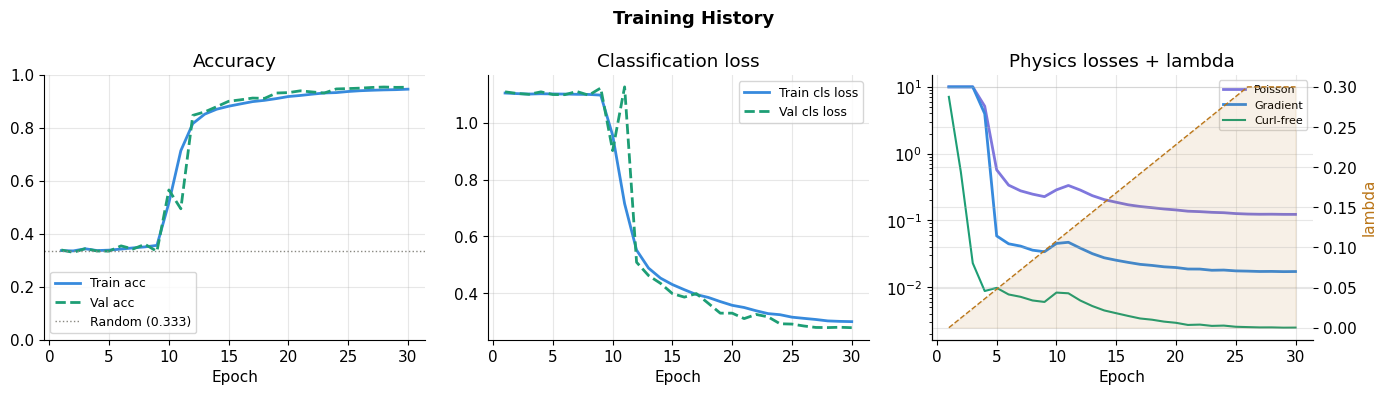

Saved -> /kaggle/working/plots/training_history.png


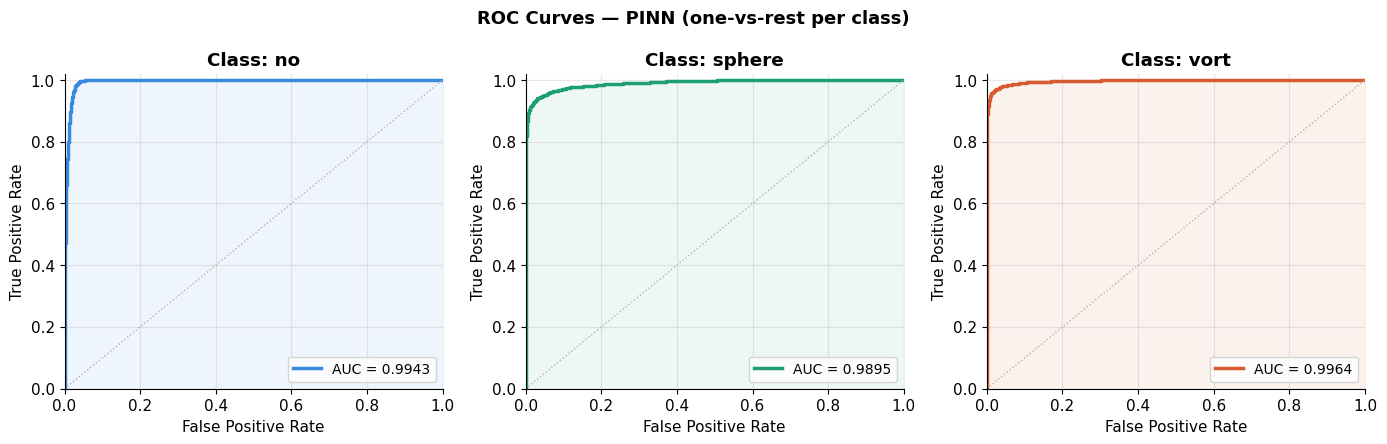

Saved -> /kaggle/working/plots/roc_curves.png

Per-class AUC : no=0.9943  sphere=0.9895  vort=0.9964
Macro AUC     : 0.9934
Val accuracy  : 95.33%

All plots saved to: /kaggle/working/plots/


In [16]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL 10 — ROC curves + training history plots
# ══════════════════════════════════════════════════════════════════════════════
import matplotlib
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve
 
matplotlib.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 11, "axes.grid": True, "grid.alpha": 0.3,
})
 
# ── Load history ──────────────────────────────────────────────────────────────
with open(Path(CKPT_DIR) / "history.json") as f:
    history = json.load(f)
 
epochs    = [h["epoch"]                  for h in history]
train_acc = [h["train_acc"]              for h in history]
val_acc   = [h["val_acc"]               for h in history]
train_cls = [h["train_cls"]              for h in history]
val_cls   = [h["val_cls"]               for h in history]
phys_pois = [h.get("train_phys_pois", 0) for h in history]
phys_curl = [h.get("train_phys_curl", 0) for h in history]
phys_grad = [h.get("train_phys_grad", 0) for h in history]
lam_vals  = [h["lam"]                   for h in history]
 
# ── Load best model for ROC ───────────────────────────────────────────────────
plot_model = GravLensPINN(in_channels=1, num_classes=3, dropout_p=0.2).to(device)
state = torch.load(str(Path(CKPT_DIR) / "best_model.pt"), map_location=device)
plot_model.load_state_dict(state)   # always works — no "module." prefixes
plot_model.eval()
 
vds = DeepLenseDataset(VAL_DIR, build_transforms(False))
vl  = DataLoader(vds, batch_size=256, shuffle=False, num_workers=2, pin_memory=True)
 
all_probs, all_labels = [], []
with torch.no_grad():
    for imgs, labels in vl:
        p = F.softmax(plot_model(imgs.to(device))["logits"], -1)
        all_probs.append(p.cpu()); all_labels.append(labels)
 
probs  = torch.cat(all_probs).numpy()
labels = torch.cat(all_labels).numpy()
 
# ── Plot 1: Training history ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle("Training History", fontsize=13, fontweight="bold")
 
ax = axes[0]
ax.plot(epochs, train_acc, color="#378ADD", lw=2, label="Train acc")
ax.plot(epochs, val_acc,   color="#1D9E75", lw=2, linestyle="--", label="Val acc")
ax.axhline(1/3, color="#888780", lw=1, linestyle=":", label="Random (0.333)")
ax.set_title("Accuracy"); ax.set_xlabel("Epoch")
ax.set_ylim(0, 1); ax.legend(fontsize=9)
 
ax = axes[1]
ax.plot(epochs, train_cls, color="#378ADD", lw=2, label="Train cls loss")
ax.plot(epochs, val_cls,   color="#1D9E75", lw=2, linestyle="--", label="Val cls loss")
ax.set_title("Classification loss"); ax.set_xlabel("Epoch"); ax.legend(fontsize=9)
 
ax = axes[2]
ax.plot(epochs, phys_pois, color="#7F77DD", lw=2,   label="Poisson")
ax.plot(epochs, phys_grad, color="#378ADD", lw=2,   label="Gradient")
ax.plot(epochs, phys_curl, color="#1D9E75", lw=1.5, label="Curl-free")
ax2 = ax.twinx()
ax2.fill_between(epochs, lam_vals, alpha=0.1, color="#BA7517")
ax2.plot(epochs, lam_vals, color="#BA7517", lw=1, linestyle="--", label="lambda")
ax2.set_ylabel("lambda", color="#BA7517")
ax.set_title("Physics losses + lambda"); ax.set_xlabel("Epoch")
ax.legend(fontsize=8, loc="upper right")
try: ax.set_yscale("log")
except Exception: pass
 
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/training_history.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved -> {SAVE_DIR}/training_history.png")
 
# ── Plot 2: Per-class ROC curves ──────────────────────────────────────────────
COLORS = ["#378ADD", "#1D9E75", "#D85A30"]
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
fig.suptitle("ROC Curves — PINN (one-vs-rest per class)", fontsize=13, fontweight="bold")
 
aucs = []
for i, (cls, color) in enumerate(zip(CLASS_NAMES, COLORS)):
    binary      = (labels == i).astype(int)
    fpr, tpr, _ = roc_curve(binary, probs[:, i])
    auc_val     = roc_auc_score(binary, probs[:, i])
    aucs.append(auc_val)
 
    ax = axes[i]
    ax.plot(fpr, tpr, color=color, lw=2.5, label=f"AUC = {auc_val:.4f}")
    ax.plot([0, 1], [0, 1], color="#B4B2A9", lw=1, linestyle=":")
    ax.fill_between(fpr, tpr, alpha=0.08, color=color)
    ax.set_title(f"Class: {cls}", fontweight="bold")
    ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
    ax.legend(loc="lower right", fontsize=10)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)
 
plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved -> {SAVE_DIR}/roc_curves.png")
 
macro_auc = roc_auc_score(labels, probs, multi_class="ovr", average="macro")
val_acc_final = (labels == probs.argmax(1)).mean()
print(f"\nPer-class AUC : no={aucs[0]:.4f}  sphere={aucs[1]:.4f}  vort={aucs[2]:.4f}")
print(f"Macro AUC     : {macro_auc:.4f}")
print(f"Val accuracy  : {val_acc_final * 100:.2f}%")
print(f"\nAll plots saved to: {SAVE_DIR}/")